# Sazonalidade e calendario

**Objetivo:** investigar se a serie apresenta padroes recorrentes associados ao calendario. Em series de internacoes, esse tipo de analise costuma revelar efeitos de inverno, de dia util/fim de semana, de feriados e de concentracao em certos periodos do ano.

Nesta etapa vamos analisar a serie por:
- ano;
- mes;
- semana epidemiologica;
- dia da semana;
- fim de semana;
- feriados e datas moveis relevantes;
- estacoes do ano.

Antes dos graficos, vamos enriquecer o dataframe com variaveis de calendario que serao reutilizadas nas proximas etapas.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

df_internacoes = pd.read_parquet(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Sazonalidade e Calendario

In [3]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

ordem_estacoes = ["Verao", "Outono", "Inverno", "Primavera"]


def classificar_estacao(data):
    mes = data.month
    if mes in [12, 1, 2]:
        return "Verao"
    if mes in [3, 4, 5]:
        return "Outono"
    if mes in [6, 7, 8]:
        return "Inverno"
    return "Primavera"


# Criamos atributos de calendario que serao usados em todos os recortes seguintes.
df_serie["ano"] = df_serie["data_dia"].dt.year
df_serie["mes"] = df_serie["data_dia"].dt.month
df_serie["mes_nome"] = pd.Categorical(
    df_serie["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)

df_serie["dia_semana_num"] = df_serie["data_dia"].dt.dayofweek
df_serie["dia_semana_nome"] = pd.Categorical(
    df_serie["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

df_serie["fim_de_semana"] = df_serie["dia_semana_num"].isin([5, 6])
df_serie["fim_de_semana_label"] = np.where(df_serie["fim_de_semana"], "Fim de semana", "Dia util")
df_serie["estacao"] = pd.Categorical(
    df_serie["data_dia"].apply(classificar_estacao),
    categories=ordem_estacoes,
    ordered=True,
)

# Semana epidemiologica com inicio no domingo.
ref_epi = (df_serie["data_dia"] + pd.Timedelta(days=1)).dt.isocalendar()
df_serie["ano_epi"] = ref_epi.year.astype(int)
df_serie["semana_epi"] = ref_epi.week.astype(int)

# Removendo colunas da rodada anterior para que a celula possa ser executada mais de uma vez sem duplicar informacao.
df_serie = df_serie.drop(columns=["nome_data_especial", "categoria_data_especial", "is_data_especial"], errors="ignore")

display(
    df_serie[
        [
            "data_dia",
            "num_internacoes",
            "ano",
            "mes_nome",
            "semana_epi",
            "dia_semana_nome",
            "fim_de_semana_label",
            "estacao"
        ]
    ].head(10)
)

,data_dia,num_internacoes,ano,mes_nome,semana_epi,dia_semana_nome,fim_de_semana_label,estacao
0,2008-01-01,79,2008,Jan,1,Ter,Dia util,Verao
1,2008-01-02,46,2008,Jan,1,Qua,Dia util,Verao
2,2008-01-03,53,2008,Jan,1,Qui,Dia util,Verao
3,2008-01-04,46,2008,Jan,1,Sex,Dia util,Verao
4,2008-01-05,42,2008,Jan,1,Sab,Fim de semana,Verao
5,2008-01-06,28,2008,Jan,2,Dom,Fim de semana,Verao
6,2008-01-07,36,2008,Jan,2,Seg,Dia util,Verao
7,2008-01-08,50,2008,Jan,2,Ter,Dia util,Verao
8,2008-01-09,39,2008,Jan,2,Qua,Dia util,Verao
9,2008-01-10,46,2008,Jan,2,Qui,Dia util,Verao


### Recorte por ano e por mes

Aqui verificamos se o nivel da serie muda de um ano para outro e em quais meses a demanda costuma ser maior ou menor. Isso ajuda a separar tendencia estrutural de sazonalidade anual.

,ano,total_anual,media_diaria,mediana_diaria,maximo_diario
0,2008,20733,56.65,56.0,121
1,2009,22437,61.47,60.0,171
2,2010,22802,62.47,61.0,125
3,2011,17621,48.28,47.0,101
4,2012,14617,39.94,36.0,87
5,2013,13036,35.72,34.0,83
6,2014,11382,31.18,31.0,60
7,2015,13927,38.16,35.0,96
8,2016,10358,28.30,25.0,63
9,2017,9818,26.90,26.0,56


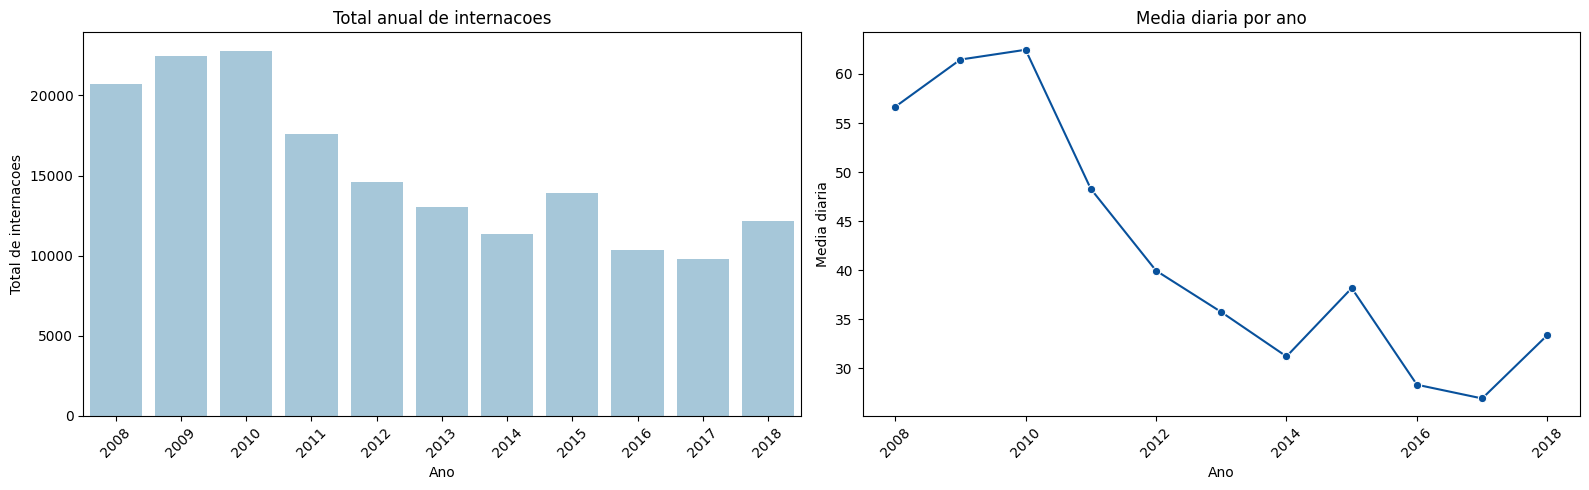

In [4]:
# Resumo anual para enxergar mudancas de nivel ao longo do tempo.
resumo_anual = (
    df_serie.groupby("ano")["num_internacoes"]
    .agg(total_anual="sum", media_diaria="mean", mediana_diaria="median", maximo_diario="max")
    .reset_index()
)

display(resumo_anual.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_anual, x="ano", y="total_anual", color="#9ecae1", ax=axes[0])
axes[0].set_title("Total anual de internacoes")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Total de internacoes")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=resumo_anual, x="ano", y="media_diaria", marker="o", color="#08519c", ax=axes[1])
axes[1].set_title("Media diaria por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Media diaria")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

,mes,media,mediana,desvio_padrao,mes_nome
0,1,29.91,28.0,12.65,Jan
1,2,32.02,29.0,15.49,Fev
2,3,39.01,36.0,17.72,Mar
3,4,55.98,51.0,24.59,Abr
4,5,59.41,55.0,22.44,Mai
5,6,52.13,49.0,17.32,Jun
6,7,49.39,46.0,20.20,Jul
7,8,42.01,38.0,16.89,Ago
8,9,38.53,36.0,15.45,Set
9,10,37.22,33.0,16.94,Out


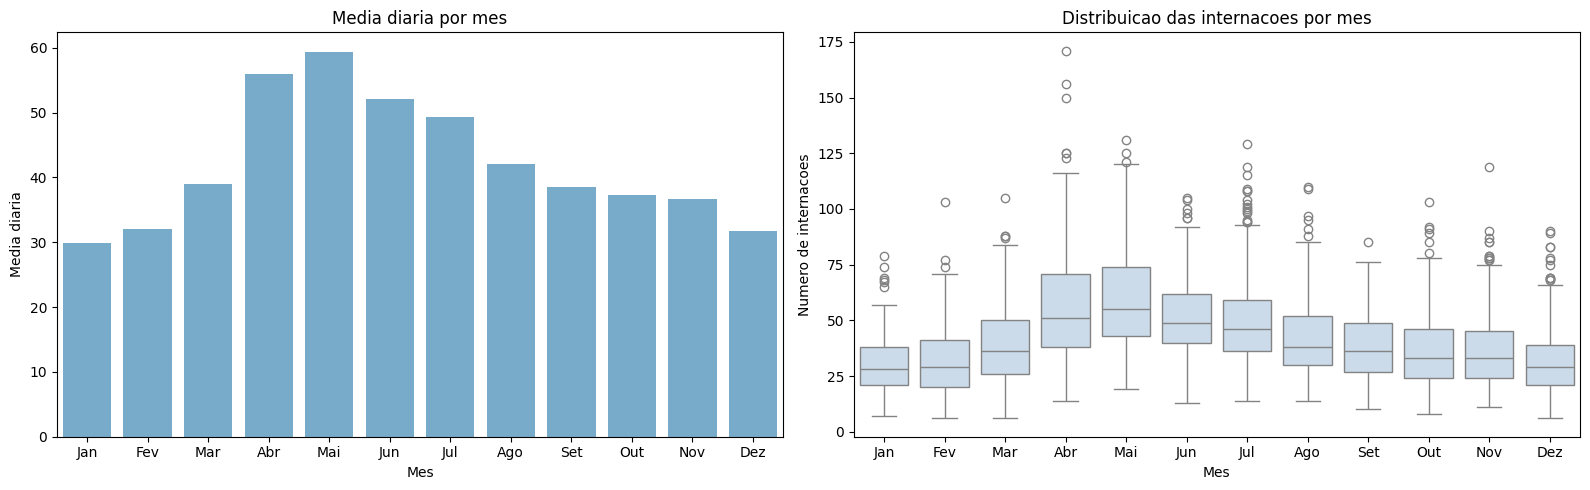

In [5]:
# Resumo mensal para identificar meses com comportamento tipicamente mais alto ou mais baixo.
resumo_mensal = (
    df_serie.groupby(["mes"])["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
    .sort_values("mes")
    .round(2)
)

resumo_mensal["mes_nome"] = resumo_mensal["mes"].map(meses)

display(resumo_mensal)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_mensal, x="mes_nome", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="mes_nome", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao das internacoes por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Recorte por semana epidemiologica

A semana epidemiologica ajuda a suavizar a leitura da sazonalidade ao longo do ano. Em saude publica, esse recorte costuma ser mais informativo do que olhar apenas o mes, porque mostra melhor o inicio, a subida e o recuo das ondas.

,semana_epi,media,mediana
0,1,32.36,30.0
1,2,31.40,29.0
2,3,28.99,28.0
3,4,28.27,25.0
4,5,28.68,25.0
5,6,29.39,26.0
6,7,31.44,29.0
7,8,32.87,30.0
8,9,35.38,33.0
9,10,36.36,32.0


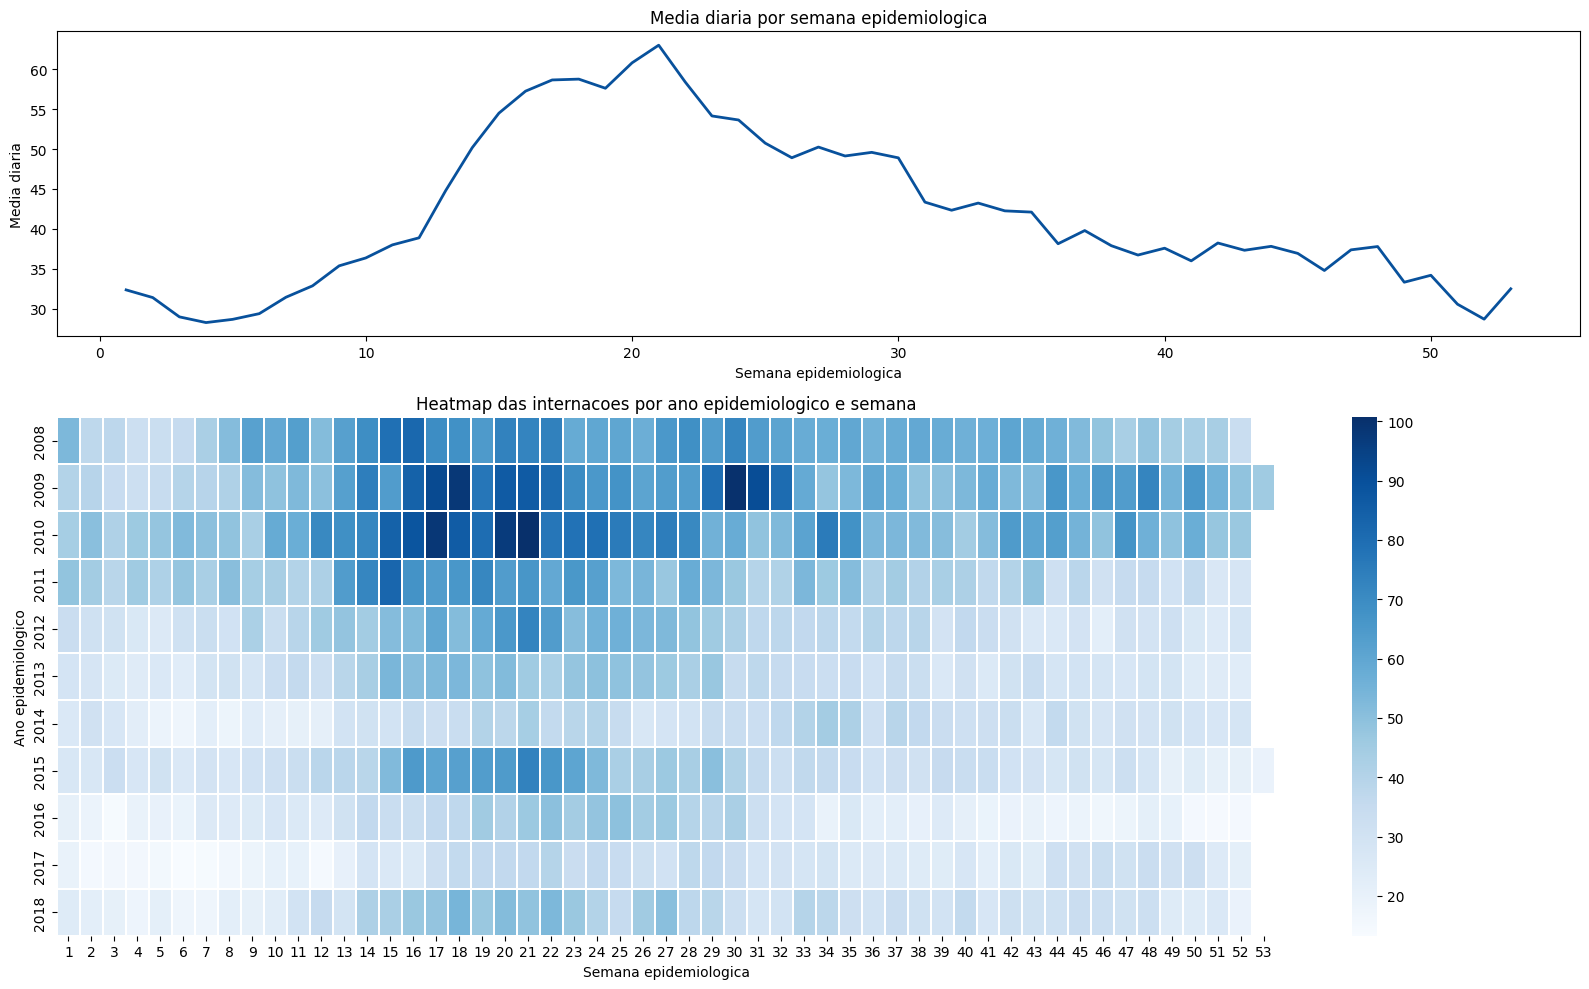

In [6]:
# Media diaria por semana epidemiologica ao longo de toda a serie.
resumo_semana_epi = (
    df_serie.groupby("semana_epi")["num_internacoes"]
    .agg(media="mean", mediana="median")
    .reset_index()
)

display(resumo_semana_epi.round(2).head(15))

# Heatmap ano x semana para observar se os picos semanais se repetem nos mesmos periodos.
heatmap_semana_epi = (
    df_serie.groupby(["ano_epi", "semana_epi"])["num_internacoes"]
    .mean()
    .reset_index()
    .pivot(index="ano_epi", columns="semana_epi", values="num_internacoes")
)

ano_min = int(df_serie["ano"].min())
ano_max = int(df_serie["ano"].max())
heatmap_semana_epi = heatmap_semana_epi.loc[(heatmap_semana_epi.index >= ano_min) & (heatmap_semana_epi.index <= ano_max)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [1, 1.7]})

sns.lineplot(data=resumo_semana_epi, x="semana_epi", y="media", color="#08519c", linewidth=2, ax=axes[0])
axes[0].set_title("Media diaria por semana epidemiologica")
axes[0].set_xlabel("Semana epidemiologica")
axes[0].set_ylabel("Media diaria")

sns.heatmap(heatmap_semana_epi, cmap="Blues", linewidths=0.1, ax=axes[1])
axes[1].set_title("Heatmap das internacoes por ano epidemiologico e semana")
axes[1].set_xlabel("Semana epidemiologica")
axes[1].set_ylabel("Ano epidemiologico")

plt.tight_layout()
plt.show()

### Dia da semana, fim de semana e datas especiais

Esse bloco ajuda a identificar padrao operacional ou assistencial. Diferencas fortes entre dias uteis e fins de semana podem refletir tanto comportamento real da demanda quanto dinamica de atendimento, registro ou adiamento de internacoes eletivas.

Nas datas especiais, combinamos feriados oficiais e algumas datas moveis relevantes para o contexto brasileiro, como Carnaval, Sexta-feira Santa e Corpus Christi.

,dia_semana_nome,media,mediana,desvio_padrao
0,Seg,49.32,45.0,23.35
1,Ter,47.63,43.0,22.40
2,Qua,45.87,43.0,18.58
3,Qui,44.37,41.0,19.76
4,Sex,43.56,40.0,18.49
5,Sab,33.19,29.5,15.54
6,Dom,30.32,28.0,13.74


,fim_de_semana_label,media,mediana,desvio_padrao
0,Dia util,46.15,42.0,20.71
1,Fim de semana,31.76,29.0,14.73


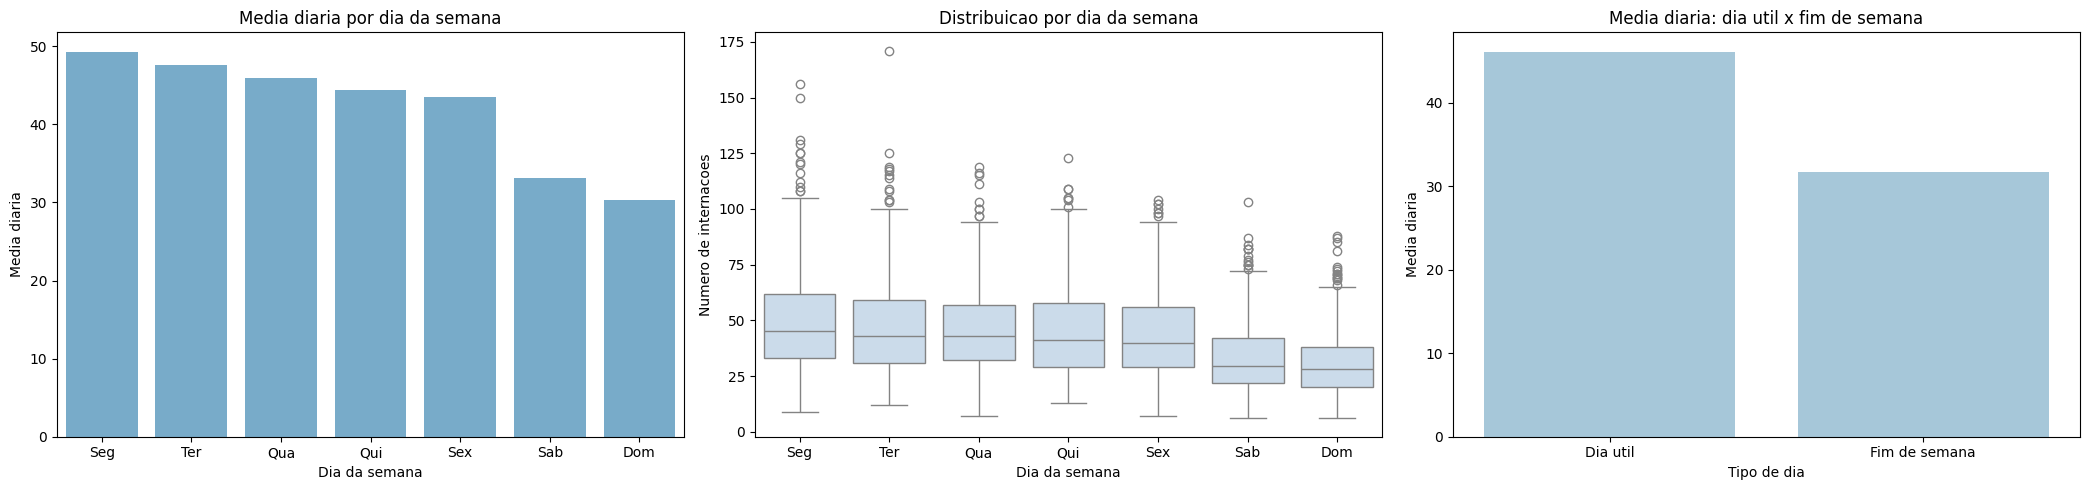

In [7]:
# Comparamos o nivel medio por dia da semana e por tipo de dia.
resumo_dia_semana = (
    df_serie.groupby(["dia_semana_num"])["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
    .sort_values("dia_semana_num")
)

resumo_dia_semana["dia_semana_nome"] = resumo_dia_semana["dia_semana_num"].map(dias_semana)

resumo_fim_de_semana = (
    df_serie.groupby("fim_de_semana_label")["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reindex(["Dia util", "Fim de semana"])
    .reset_index()
)

display(resumo_dia_semana[["dia_semana_nome", "media", "mediana", "desvio_padrao"]].round(2))
display(resumo_fim_de_semana.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.barplot(data=resumo_dia_semana, x="dia_semana_nome", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por dia da semana")
axes[0].set_xlabel("Dia da semana")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="dia_semana_nome", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao por dia da semana")
axes[1].set_xlabel("Dia da semana")
axes[1].set_ylabel("Numero de internacoes")

sns.barplot(data=resumo_fim_de_semana, x="fim_de_semana_label", y="media", color="#9ecae1", ax=axes[2])
axes[2].set_title("Media diaria: dia util x fim de semana")
axes[2].set_xlabel("Tipo de dia")
axes[2].set_ylabel("Media diaria")

plt.tight_layout()
plt.show()

### Estacoes do ano

Como a serie trata de internacoes respiratorias, comparar o comportamento entre estacoes e especialmente importante. No hemisferio sul, o inverno corresponde aos meses de junho, julho e agosto.

,estacao,media,mediana,desvio_padrao
0,Verao,31.22,28.0,14.52
1,Outono,51.41,48.0,23.49
2,Inverno,47.79,44.0,18.68
3,Primavera,37.47,34.0,16.42


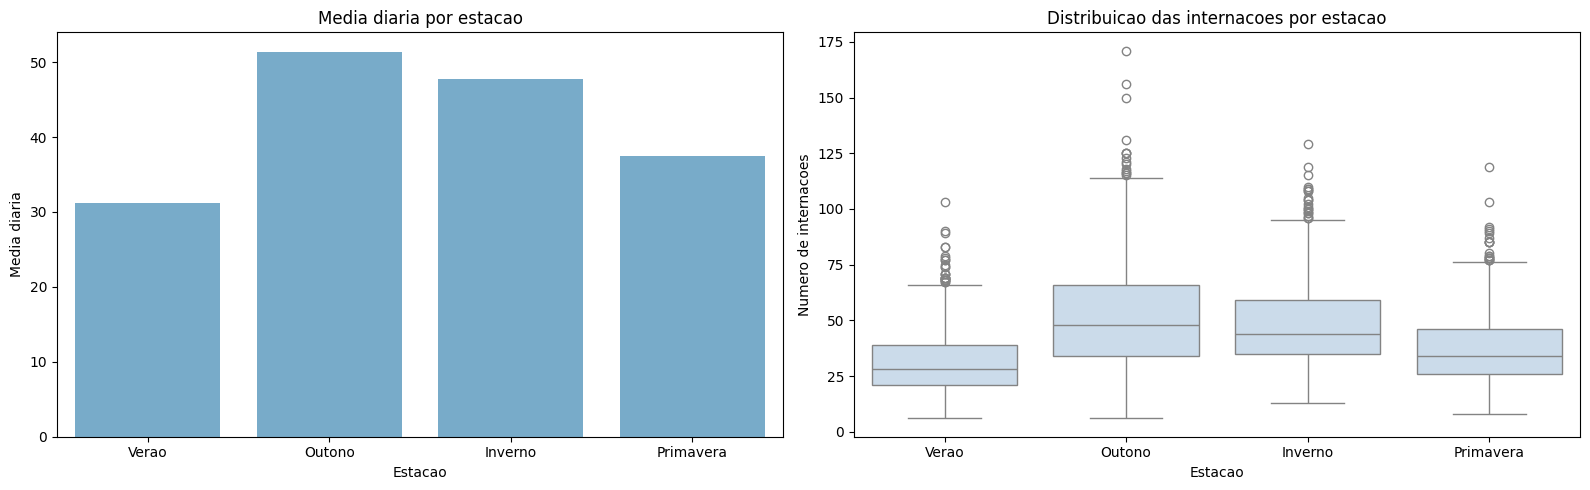

In [8]:
# Resumo por estacao para verificar efeito sazonal mais amplo do clima.
resumo_estacao = (
    df_serie.groupby("estacao")["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
)

display(resumo_estacao.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_estacao, x="estacao", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por estacao")
axes[0].set_xlabel("Estacao")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="estacao", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao das internacoes por estacao")
axes[1].set_xlabel("Estacao")
axes[1].set_ylabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

Os recortes de calendário continuam mostrando **sazonalidade anual forte** e também **efeito semanal relevante**. No agregado por ano, a heterogeneidade entre períodos segue evidente: **2012** teve média diária de **557,0 internações**, **2013** ficou em **461,9** e **2015** em **418,2**, enquanto anos mais baixos como **2017 (240,4)** e **2018 (265,3)** aparecem em outro patamar. Isso reforça que a série combina sazonalidade com **mudanças importantes de nível ao longo do tempo**.

No recorte mensal, o padrão sazonal permanece bem marcado: as médias sobem de **março (336,9)** para **abril (483,0)**, atingem pico em **maio (554,2)** e seguem elevadas em **junho (497,3)** e **julho (441,1)**. O menor nível médio ocorreu em **dezembro (256,7)**. Assim, o mês de maior média ficou cerca de **116% acima** do mês de menor média, confirmando uma sazonalidade anual intensa.

A leitura por semana epidemiológica confirma esse comportamento. As maiores médias se concentram entre as **semanas 16 e 25**, com destaque para **19 a 22** e pico na **semana 21 (589,5)**. Isso sugere que a parte final do outono e o início do inverno concentram as ondas mais fortes de internação respiratória.

Também há um **efeito semanal consistente**: **segunda (431,5)**, **quarta (419,5)** e **terça (409,7)** ficam acima de **sábado (290,9)** e **domingo (276,4)**. Ao agrupar em dois blocos, os **dias úteis (405,9)** ficaram cerca de **43% acima** dos **fins de semana (283,6)**. Esse diferencial pode refletir tanto dinâmica assistencial real quanto efeito de registro e admissão após o fim de semana.

Na comparação por estação, o maior nível médio ocorreu no **outono (457,8)**, seguido do **inverno (437,2)**, enquanto o **verão (266,0)** foi o período de menor demanda. Portanto, a subida relevante começa antes do inverno, principalmente na transição de **março a junho**.

**Possíveis análises e consequências**
- A sazonalidade anual forte sustenta o uso de variáveis de mês, semana epidemiológica ou termos sazonais no modelo.
- O efeito dia útil/fim de semana indica que variáveis de calendário devem entrar como features obrigatórias de previsão.
- Como os picos se concentram entre **abril e julho** e nas **semanas 16 a 25**, vale testar janelas de alerta antecipado no fim do verão e início do outono.
- A diferença importante entre anos reforça a necessidade de investigar quebras estruturais e eventos anormais antes da modelagem final.